In [110]:
import itertools
import math
import pathlib
import time
from dataclasses import dataclass
from pathlib import Path

import fastjet as fj
import h5py
import hdf5plugin  # noqa
import numpy as np
import pandas
from astropy.io import fits
from astropy.io.fits import BinTableHDU
from matplotlib import colors
from matplotlib import pyplot as plt

from funbin import funbin
from funbin.einstein import aperiodic_monotile
from funbin.penrose import penrose_tiling

In [2]:
plt.rc("figure", figsize=(5, 5))
plt.rc("image", cmap="inferno")
plt.rc("axes", titlesize=11)

# Penrose tilings

## Penrose P1

H-G diagram with HYG star catalog

- [Data source](https://codeberg.org/astronexus/hyg)
- Based loosely on [this notebook](https://github.com/RobertoIA/Hertzsprung-Russell)


In [3]:
hyg = pandas.read_csv("misc/hyg_v42.csv.gz")
hyg = hyg[["absmag", "ci"]]
hyg.dropna(inplace=True)
hyg = hyg[hyg["ci"] < 2.25]

print(hyg.size)
hyg.head()

235100


,absmag,ci
0,4.850,0.656
1,2.390,0.482
2,5.866,0.999
3,-1.619,-0.019
4,2.421,0.370


In [4]:
start = time.time()
penrose_p1 = penrose_tiling(kind="P1", bins=(60, 60))
print(f"Tiling produced in {time.time() - start:.3f} sec")

Tiling produced in 11.932 sec


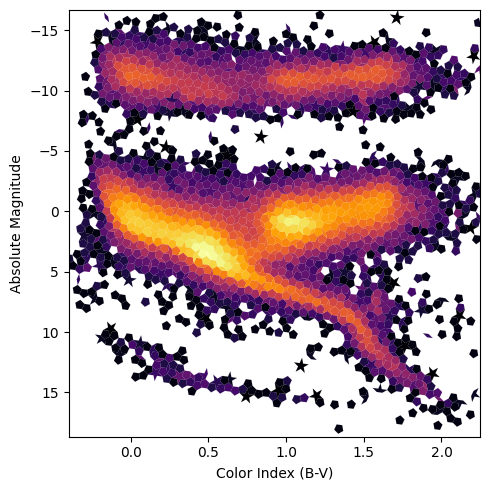

In [5]:
fig, ax = plt.subplots()

pc = funbin(
    ax,
    x=hyg["ci"].to_numpy(),
    y=hyg["absmag"].to_numpy(),
    tiling=penrose_p1,
    norm="log",
)
# fig.colorbar(pc, ax=ax)
# ax.set_title("H-R diagram with Penrose P1 tiling")
ax.set_xlabel("Color Index (B-V)")
ax.set_ylabel("Absolute Magnitude")
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymax, ymin)

fig.tight_layout()
fig.savefig("media/paper/hr-penrose-p1.pdf")

## Penrose P3

BBH parameter posterior sample from LVK data release. Should have mass ratio at ~golden ratio to make a joke about fat and thick rombi.

- LVK parameter estimation data [release](https://zenodo.org/records/8177023)


In [6]:
available_files = sorted(
    itertools.chain.from_iterable((Path("misc").glob(prefix + "IGWN*.h5") for prefix in ("", "_")))
)
print(*available_files, sep="\n")

misc/IGWN-GWTC3p0-v2-GW191103_012549_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191105_143521_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191109_010717_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191113_071753_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191126_115259_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191129_134029_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191204_171526_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191215_223052_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW191215_223052_PEDataRelease_mixed_nocosmo.h5
misc/IGWN-GWTC3p0-v2-GW200208_130117_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW200302_015811_PEDataRelease_mixed_cosmo.h5
misc/IGWN-GWTC3p0-v2-GW200308_173609_PEDataRelease_mixed_cosmo.h5
misc/_IGWN-GWTC3p0-v2-GW191222_033537_PEDataRelease_mixed_cosmo.h5
misc/_IGWN-GWTC3p0-v2-GW191230_180458_PEDataRelease_mixed_cosmo.h5
misc/_IGWN-GWTC3p0-v2-GW200105_162426_PEDataRelease_mixed_nocosmo.h5
mis

In [7]:
def parse_event_name(filename: str | Path) -> tuple[str, bool]:
    stem = Path(filename).stem
    *_, longname = stem.split("-")
    event_name = longname.split("_")[0]
    is_cosmo = not stem.endswith("nocosmo")
    return event_name, is_cosmo


def read_posterior_sample(filename: str | Path) -> tuple[np.ndarray, list[str]]:
    with h5py.File(filename) as f:
        ps = f["C01:IMRPhenomXPHM"]["posterior_samples"]  # type: ignore
        # source of this monstrosity: numpy structured arrays
        # https://git.ligo.org/lscsoft/pesummary/-/blob/1191d830d9eed4eba6d4f8c3cc7512fb919e5415/pesummary/core/file/formats/pesummary.py#L321
        return np.array([packed.tolist() for packed in ps]).T, list(ps.dtype.names)  # type: ignore

In [8]:
start = time.time()
penrose_p3 = penrose_tiling(kind="P3", bins=(60, 60))
print(f"Tiling produced in {time.time() - start:.3f} sec")

Tiling produced in 3.439 sec


In [9]:
file_idx = 2
# candidates:
# 2: weird bi-modal
# 7, 8, 9, 12, 13, 15, 16, 18: close to same-mass
# 10: best, mode close to 1/phi^2
# 17: beautiful and slightly bimodal
filename = available_files[file_idx]
print(f"File: {filename}")
print(f"Size: {filename.stat().st_size / (1024**2):.2f} MiB")
start = time.time()
samples, parameters = read_posterior_sample(filename)
print(f"Data loaded from {filename} in {time.time() - start:.3f} sec")

File: misc/IGWN-GWTC3p0-v2-GW191109_010717_PEDataRelease_mixed_cosmo.h5
Size: 221.93 MiB
Data loaded from misc/IGWN-GWTC3p0-v2-GW191109_010717_PEDataRelease_mixed_cosmo.h5 in 77.508 sec


GW191109
True


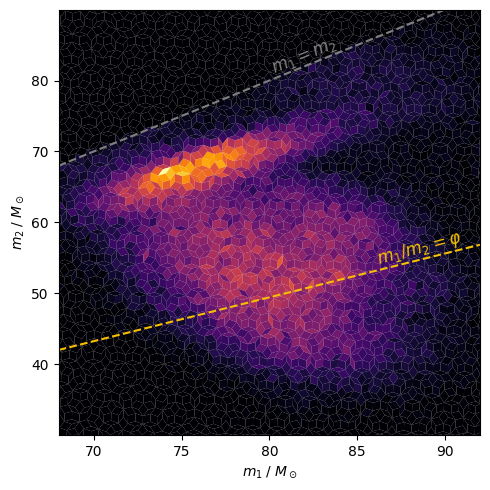

In [98]:
x_param = "mass_1"
y_param = "mass_2"

fig, ax = plt.subplots()

x_idx = parameters.index(x_param)
y_idx = parameters.index(y_param)
x_sample = samples[x_idx, :]
y_sample = samples[y_idx, :]
mask = (x_sample < 92) & (x_sample > 68) & (y_sample < 90) & (y_sample > 30)
# mask = np.ones_like(x_sample, dtype=bool)
funbin(ax, x_sample[mask], y_sample[mask], tiling=penrose_p3)
# ax.hist2d(x_sample[mask], y_sample[mask], bins=60)

xlim, ylim = ax.get_xlim(), ax.get_ylim()
m1_grid = np.linspace(*xlim, 30)
golden_ratio = 1.618033988749
ax.plot(m1_grid, m1_grid, linestyle="--", color="gray")
ax.text(80, 81.1, "$ m_1 = m_2 $", color="gray", rotation=22.5, fontsize=12)

ax.plot(m1_grid, m1_grid / golden_ratio, linestyle="--", color="xkcd:golden")
ax.text(86, 54.2, "$ m_1 / m_2 = \\varphi $", color="xkcd:golden", rotation=14.8, fontsize=12)

# ax.plot(m1_grid, m1_grid / golden_ratio ** (3 / 2), linestyle="-", color="tab:red")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

ax.set_xlabel("$m_1 \\; / \\; M_\\odot $")
ax.set_ylabel("$m_2 \\; / \\; M_\\odot$")
event_name, is_cosmo = parse_event_name(filename)
print(event_name)
print(is_cosmo)
# ax.set_title(f"Posterior for BH masses in {event_name} binned in Penrose P3 tiling")
fig.tight_layout()
fig.savefig("media/paper/bbh-posterior-penrose-p3.pdf")

## Penrose P2 (darts and kites)


In [13]:
@dataclass
class Event:
    jets: tuple[fj.PseudoJet, ...]
    MET: float

    def __post_init__(self):
        main_jets = [self.jets[0], self.jets[1]]
        main_jets.sort(key=lambda pj: pj.m())
        self.j1 = main_jets[0]
        self.j2 = main_jets[1]

    def HT(self) -> float:
        return sum(j.pt() for j in self.jets)

    def main_dijet(self) -> fj.PseudoJet:
        return self.j1 + self.j2

    def main_dijet_deltaR(self):
        return self.j1.delta_R(self.j2)


def parse_event(
    event: np.ndarray,
    verbose: bool,
    R: float = 1.0,
    min_pt_GeV: float = 20.0,
) -> Event:
    event = np.trim_zeros(event)
    event = np.reshape(event, shape=(event.size // 3, 3))

    particles = []
    for particle_data in event:
        pj = fj.PseudoJet()
        pj.reset_PtYPhiM(particle_data[0], particle_data[1], particle_data[2])
        particles.append(pj)

    jetdef = fj.JetDefinition(fj.antikt_algorithm, R)
    jet_cluster = fj.ClusterSequence(particles, jetdef)
    jets = fj.sorted_by_pt(jet_cluster.inclusive_jets(min_pt_GeV))

    MET_px = -sum(p.px() for p in particles)
    MET_py = -sum(p.py() for p in particles)
    MET = math.sqrt(MET_px**2 + MET_py**2)

    if verbose:
        print(f"{event.shape[0]} particles -> {len(jets)} jets")

    return Event(jets=jets, MET=MET)


def parse_events(filename: str, count: int, verbose: bool = False) -> list[Event]:
    with h5py.File(filename) as f:
        table: h5py.Dataset = f["df"]["block0_values"]  # type: ignore
        events: list[Event] = []
        for idx in range(count):
            events.append(parse_event(table[idx], verbose=verbose))
        return events

In [104]:
lhco_events = parse_events("misc/events_LHCO2020_BlackBox1.h5", count=20000, verbose=False);

In [100]:
start = time.time()
penrose_p2 = penrose_tiling(kind="P2", bins=(60, 60))
print(f"Tiling produced in {time.time() - start:.3f} sec")

Tiling produced in 5.705 sec


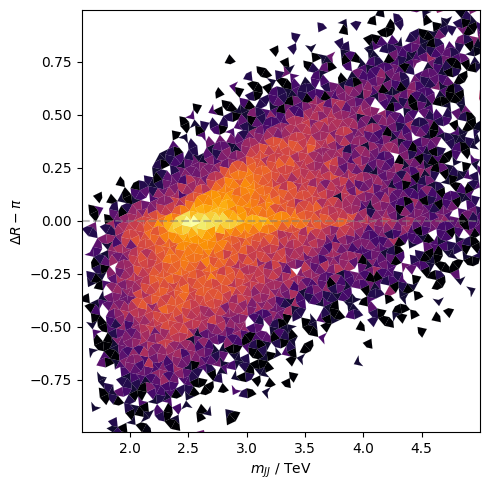

In [ ]:
fig, ax = plt.subplots()

x_sample = np.array([e.main_dijet().m() for e in lhco_events])
y_sample = np.array([e.main_dijet_deltaR() for e in lhco_events])
deltaR_width = 1.0
mask = (x_sample > 1000) & (x_sample < 5000) & (y_sample > math.pi - deltaR_width) & (y_sample < math.pi + deltaR_width)
funbin(ax, x_sample[mask] / 1000, y_sample[mask] - math.pi, tiling=penrose_p2, norm="log")

ax.axhline(0, color="gray", linestyle="--", alpha=0.5)

ax.set_xlabel("$m_{JJ}$ / TeV")
ax.set_ylabel("$ \\Delta R - \\pi $")

fig.tight_layout()
fig.savefig("media/paper/lhco-mJJ-deltaR-penrose-p2.pdf")

# Aperiodic monotile

With Fermi LAT data selected with

```
Object name: PSR J2032+4127
    Coordinates: (RA = 308.055, Dec = 41.4568)
Coordinate system: J2000
Search radius (degrees): 22
Observation dates: 2025-01-01 00:00:00, 2026-01-01 00:00:00
Time system: Gregorian
    MET time range(757382405, 788918405)
Energy range (MeV): 200, 10000
LAT data type: Photon
Spacecraft data: No
```


In [ ]:
def extract_events(files: list[str]) -> tuple[np.ndarray, np.ndarray]:
    x_sample = []
    y_sample = []
    for file in files:
        print(f"Reading {file}...")
        with fits.open(file) as hdul:
            hdu: BinTableHDU = hdul[1]  # type: ignore
            for event in hdu.data:
                x_sample.append(event["L"])
                y_sample.append(event["B"])

    print(f"Total photons extracted: {len(x_sample)}")
    return np.array(x_sample), np.array(y_sample)

In [107]:
files = [str(p.resolve()) for p in pathlib.Path("misc/Fermi-data/3-pulsar-region").glob("*.fits")]
x_sample, y_sample = extract_events(files)

Reading /Users/njvh/Documents/Personal/funbin/misc/Fermi-data/3-pulsar-region/L260329163526A589599217_PH00.fits...
Reading /Users/njvh/Documents/Personal/funbin/misc/Fermi-data/3-pulsar-region/L260329163526A589599217_PH01.fits...
Reading /Users/njvh/Documents/Personal/funbin/misc/Fermi-data/3-pulsar-region/L260329163526A589599217_PH02.fits...
Total photons extracted: 3847984


In [129]:
start = time.time()
einstein_tiling = aperiodic_monotile(bins=(70, 70))
print(f"Tiling produced in {time.time() - start:.3f} sec")

Tiling produced in 46.029 sec


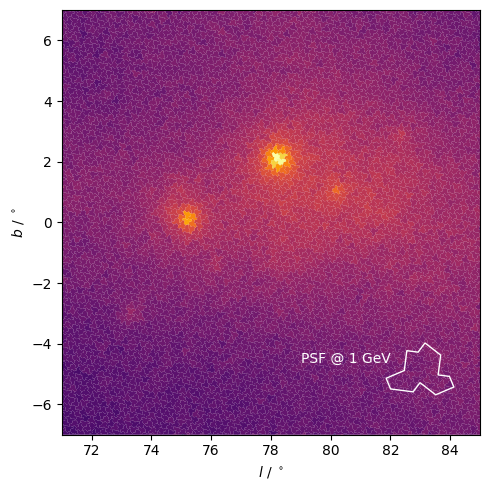

In [184]:
from matplotlib.patches import Polygon

from funbin.geometry import Point

fig, ax = plt.subplots()

mask = np.ones_like(x_sample, dtype=bool)
halfwidth = 7
mask &= (np.abs(y_sample) < halfwidth) & (np.abs(x_sample - 78) < halfwidth)

# ax.hist2d(x_sample[mask], y_sample[mask], bins=70, norm=colors.PowerNorm(gamma=0.5))
funbin(ax, x_sample[mask], y_sample[mask], tiling=einstein_tiling, norm=colors.PowerNorm(gamma=0.5))

ax.set_xlabel("$ l $ / $^\\circ$")
ax.set_ylabel("$ b $ / $^\\circ$")

hat = einstein_tiling[0]
hat.translated(-1 * hat.centroid)
hat = hat.rotated(2.8 * math.pi / 4)
psf_hat = hat.scaled(math.sqrt(math.pi * (0.8) ** 2 / hat.area))
psf_center = Point(83, -5)
psf_hat = psf_hat.translated(psf_center - psf_hat.centroid)
ax.add_artist(Polygon(psf_hat.verts, facecolor="none", edgecolor="white"))
ax.text(psf_center.x - 1.0, psf_center.y + 0.5, "PSF @ 1 GeV", ha="right", va="center", color="white")

fig.tight_layout()
fig.savefig("media/paper/fermi-lat-three-pulsars-einstein.pdf")

# Turtle monotile

In [231]:
pulsars = pandas.read_csv("misc/pulsar-sample-p-pdot.csv", sep=";", comment="#", usecols=[1, 4], header=None)
pulsars.columns = ["P0", "P1"]
mask = (pulsars != "*").all(axis=1)
pulsars = pulsars[mask].astype(np.float32, errors="raise")

In [232]:
pulsars.head()

,P0,P1
0,0.115364,5.967030e-15
1,0.693748,2.097000e-15
2,0.315873,3.603900e-13
4,3.025301,1.280000e-16
5,1.240699,5.644600e-16


In [240]:
start = time.time()
turtle_tiling = aperiodic_monotile(bins=(40, 40), kind="turtle")
print(f"Tiling produced in {time.time() - start:.3f} sec")

Tiling produced in 14.352 sec


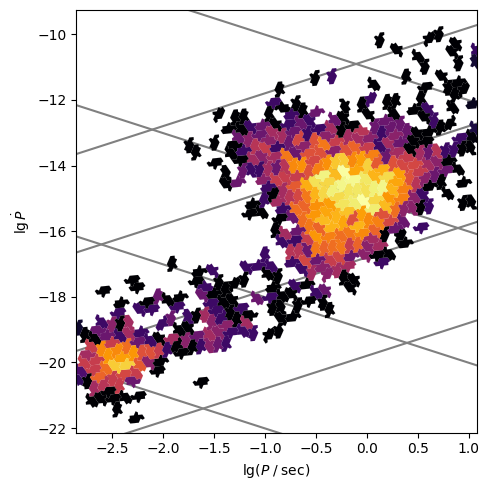

In [ ]:
fig, ax = plt.subplots()

mask = (pulsars["P1"] > 0) & (pulsars["P0"] < 20)
x_sample = np.log10(pulsars["P0"][mask])
y_sample = np.log10(pulsars["P1"][mask])
funbin(ax, x_sample[mask], y_sample[mask], tiling=turtle_tiling, norm="log")

ax.set_xlabel("$ \\lg (P \\; / \\; \\text{sec}) $ ")
ax.set_ylabel("$ \\lg \\dot{P} $")

lgP_min, lgP_max = ax.get_xlim()
lgP_grid = np.linspace(lgP_min, lgP_max, 10)
for age_yr in (1e12, 1e9, 1e6, 1e3):
    age_sec = age_yr * 365 * 24 * 60 * 60
    lgPdot = lgP_grid - np.log10(age_sec * 2)
    ax.plot(lgP_grid, lgPdot, color="gray", zorder=-10)

for lgB_1012_G in (-4, -2, 0, 2):
    lgPdot = 2 * (lgB_1012_G - 7 - np.log10(3.2)) - lgP_grid
    ax.plot(lgP_grid, lgPdot, color="gray", zorder=-10)

fig.tight_layout()
fig.savefig("media/paper/p-pdot-turtle.pdf")

# Plans and ideas

- Data: LHC Olympics
- Data: Fermi photon counts
- Data: Pulsar $P - \dot P$ diagram
- Data: More interesting posteriors
- Tile: hat, turtle
- Data: BH mass-spin diagram from [COMPAS](https://zenodo.org/records/6346444) (as in [here](https://journals.aps.org/prd/abstract/10.1103/tf4z-71rt))
- Data: SXS collaboration data from [here](https://data.black-holes.org/simulations/index.html)
